<a href="https://colab.research.google.com/github/rishikaa-14/nlp-moefcc/blob/main/moefcc_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MoEFCC NLP Pipeline
## NLP-Based Analysis of Sustainability Discourse in MoEFCC Annual Reports

Pipeline:
1. Install dependencies
2. Upload PDFs + extract text (with OCR fallback for scanned pages)
3. Preprocess + segment sentences
4. Rule-based labeling
5. Train BiGRU classifiers
6. Classify all reports
7. Visualize results

In [ ]:

!pip install -q pymupdf pdfplumber pytesseract pdf2image sentence-transformers torch torchvision tqdm scikit-learn seaborn plotly openpyxl
!apt-get install -q tesseract-ocr poppler-utils
print('✅ All dependencies installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 68.4 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 1s (234 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 118194 files and

In [ ]:
# ════════════════════════════════════════════════
# STEP 2 — Upload your PDFs
# ════════════════════════════════════════════════
import os
from google.colab import files

os.makedirs('data/raw_pdfs', exist_ok=True)
os.makedirs('data/extracted_text', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('outputs/visualizations', exist_ok=True)

print('Upload your MoEFCC annual report PDFs (you can select multiple):')
uploaded = files.upload()

for fname, content in uploaded.items():
    dest = f'data/raw_pdfs/{fname}'
    with open(dest, 'wb') as f:
        f.write(content)
    print(f'  Saved: {dest}')

print(f'\n✅ {len(uploaded)} PDF(s) uploaded')

Upload your MoEFCC annual report PDFs (you can select multiple):


Saving moefcc_2008_09.pdf to moefcc_2008_09.pdf
Saving moefcc_2009_10.pdf to moefcc_2009_10.pdf
Saving moefcc_2010_11.pdf to moefcc_2010_11.pdf
Saving moefcc_2011_12.pdf to moefcc_2011_12.pdf
Saving moefcc_2012_13.pdf to moefcc_2012_13.pdf
Saving moefcc_2013_14.pdf to moefcc_2013_14.pdf
Saving moefcc_2014_15.pdf to moefcc_2014_15.pdf
Saving moefcc_2015_16.pdf to moefcc_2015_16.pdf
Saving moefcc_2016_17.pdf to moefcc_2016_17.pdf
Saving moefcc_2017_18.pdf to moefcc_2017_18.pdf
Saving moefcc_2018_19.pdf to moefcc_2018_19.pdf
Saving moefcc_2019_20.pdf to moefcc_2019_20.pdf
Saving moefcc_2020_21.pdf to moefcc_2020_21.pdf
Saving moefcc_2021_22.pdf to moefcc_2021_22.pdf
Saving moefcc_2022_23.pdf to moefcc_2022_23.pdf
Saving moefcc_2023_24.pdf to moefcc_2023_24.pdf
Saving moefcc_2024_25.pdf to moefcc_2024_25.pdf
Saving moefcc_2025_26.pdf to moefcc_2025_26.pdf
  Saved: data/raw_pdfs/moefcc_2008_09.pdf
  Saved: data/raw_pdfs/moefcc_2009_10.pdf
  Saved: data/raw_pdfs/moefcc_2010_11.pdf
  Saved: d

In [ ]:
# ════════════════════════════════════════════════
# STEP 3 — Extract text from PDFs
# Handles both text-based and scanned/image PDFs
# ════════════════════════════════════════════════
!pip install -q pymupdf
import fitz
import pytesseract
from PIL import Image
from pdf2image import convert_from_path
import re
from tqdm import tqdm

MIN_TEXT_CHARS = 100

def clean_text(text):
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'[ \t]{2,}', ' ', text)
    text = re.sub(r'\f', '\n\n', text)
    return text.strip()

def extract_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    full_text = []
    for page_num in range(len(doc)):
        page = doc[page_num]
        text = page.get_text('text')
        if len(text.strip()) < MIN_TEXT_CHARS:
            try:
                images = convert_from_path(pdf_path, first_page=page_num+1,
                                           last_page=page_num+1, dpi=300)
                if images:
                    text = pytesseract.image_to_string(images[0], lang='eng')
            except Exception as e:
                print(f'    OCR failed page {page_num+1}: {e}')
        if text.strip():
            full_text.append(f'[PAGE {page_num+1}]\n{text}')
    doc.close()
    return clean_text('\n\n'.join(full_text))

pdf_files = [f for f in os.listdir('data/raw_pdfs') if f.lower().endswith('.pdf')]
print(f'Found {len(pdf_files)} PDF(s)\n')

for pdf_file in pdf_files:
    pdf_path = f'data/raw_pdfs/{pdf_file}'
    match = re.search(r'(20\d{2})', pdf_file)
    year = match.group(1) if match else 'unknown'
    out_path = f'data/extracted_text/{os.path.splitext(pdf_file)[0]}.txt'
    print(f'[{year}] Extracting: {pdf_file}')
    text = extract_pdf(pdf_path)
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(f'YEAR: {year}\nSOURCE: {pdf_file}\n\n{text}')
    print(f'  Done — {len(text):,} characters')

print('\n✅ Extraction complete')

Found 18 PDF(s)

[2011] Extracting: moefcc_2011_12.pdf
  Done — 993,833 characters
[2014] Extracting: moefcc_2014_15.pdf
  Done — 724,147 characters
[2012] Extracting: moefcc_2012_13.pdf
  Done — 1,178,662 characters
[2015] Extracting: moefcc_2015_16.pdf
  Done — 567,215 characters
[2009] Extracting: moefcc_2009_10.pdf
  Done — 853,504 characters
[2013] Extracting: moefcc_2013_14.pdf
  Done — 1,358,163 characters
[2021] Extracting: moefcc_2021_22.pdf
  Done — 724,868 characters
[2010] Extracting: moefcc_2010_11.pdf
  Done — 794,056 characters
[2023] Extracting: moefcc_2023_24.pdf
  Done — 642,419 characters
[2018] Extracting: moefcc_2018_19.pdf
  Done — 581,411 characters
[2017] Extracting: moefcc_2017_18.pdf
  Done — 558,150 characters
[2025] Extracting: moefcc_2025_26.pdf
  Done — 701,978 characters
[2022] Extracting: moefcc_2022_23.pdf
  Done — 596,968 characters
[2020] Extracting: moefcc_2020_21.pdf
  Done — 663,666 characters
[2016] Extracting: moefcc_2016_17.pdf
  Done — 543,747 

In [ ]:
# ════════════════════════════════════════════════
# STEP 4 — Preprocess and segment sentences
# ════════════════════════════════════════════════
import nltk
import pandas as pd
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

MIN_WORDS, MAX_WORDS = 6, 120

def clean_page_text(text):
    text = re.sub(r'\[PAGE \d+\]', '', text)
    text = re.sub(r'^\s*\d+\s*$', '', text, flags=re.MULTILINE)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

def is_valid(sent):
    words = sent.split()
    if len(words) < MIN_WORDS or len(words) > MAX_WORDS: return False
    if re.match(r'^[\d\s\.\,\%\-\/]+$', sent): return False
    return True

all_rows = []
sid = 0
for txt_file in os.listdir('data/extracted_text'):
    if not txt_file.endswith('.txt'): continue
    with open(f'data/extracted_text/{txt_file}', 'r', encoding='utf-8') as f:
        raw = f.read()
    year_match = re.search(r'YEAR:\s*(20\d{2})', raw)
    year = year_match.group(1) if year_match else 'unknown'
    raw  = re.sub(r'^YEAR:.*\nSOURCE:.*\n', '', raw)
    cleaned   = clean_page_text(raw)
    sentences = sent_tokenize(cleaned)
    valid = [s.strip() for s in sentences if is_valid(s.strip())]
    for sent in valid:
        all_rows.append({'sentence_id': f'S{sid:06d}', 'year': year,
                         'source_file': txt_file, 'sentence': sent})
        sid += 1
    print(f'[{year}] {len(valid)} valid sentences')

df = pd.DataFrame(all_rows)
df.to_csv('data/processed/sentences.csv', index=False)
print(f'\n✅ Total sentences: {len(df):,}')
print(df['year'].value_counts().sort_index())

[2017] 7 valid sentences
[2009] 4610 valid sentences
[2022] 2800 valid sentences
[2025] 3599 valid sentences
[2024] 3526 valid sentences
[2010] 4346 valid sentences
[2015] 14 valid sentences
[2019] 2595 valid sentences
[2021] 3852 valid sentences
[2011] 5426 valid sentences
[2013] 6942 valid sentences
[2020] 3326 valid sentences
[2023] 3197 valid sentences
[2012] 6101 valid sentences
[2016] 12 valid sentences
[2018] 3060 valid sentences
[2008] 4389 valid sentences
[2014] 3709 valid sentences

✅ Total sentences: 61,511
year
2008    4389
2009    4610
2010    4346
2011    5426
2012    6101
2013    6942
2014    3709
2015      14
2016      12
2017       7
2018    3060
2019    2595
2020    3326
2021    3852
2022    2800
2023    3197
2024    3526
2025    3599
Name: count, dtype: int64


In [ ]:
# ════════════════════════════════════════════════
# STEP 5 — Rule-based labeling
# ════════════════════════════════════════════════
THEME_KW = {
    'water_conservation':   ['water','river','lake','wetland','groundwater','irrigation','watershed','flood','drought','dam','reservoir'],
    'biodiversity':         ['biodiversity','wildlife','species','forest','flora','fauna','ecosystem','habitat','national park','sanctuary','tiger','elephant','coral','marine'],
    'climate_adaptation':   ['climate change','carbon','emission','greenhouse','global warming','sea level','monsoon','cyclone','disaster','resilience','renewable energy','solar','wind energy','net zero','COP'],
    'soil_health':          ['soil','land degradation','desertification','erosion','fertility','organic matter','agriculture','crop','fertilizer','afforestation','reforestation','plantation'],
    'pollution_control':    ['pollution','air quality','particulate','smog','effluent','waste','plastic','hazardous','toxic','industrial','emission standard','clean air'],
    'eco_friendly_practices':['sustainable','green','eco','recycl','circular economy','organic','natural resource','awareness','community','scheme','programme','policy','regulation']
}
DISC_KW = {
    'aspirational':   ['aim','aspire','vision','goal','target','objective','plan to','intend','hope','strive','will be','expected to','proposed','future','by 2030','commitment'],
    'policy_oriented':['policy','act','rule','regulation','notification','guideline','framework','scheme','programme','legislation','amendment','gazette','ministry','committee'],
    'action_based':   ['launched','implemented','initiated','established','constructed','installed','conducted','organized','developed','set up','created','carried out','introduced','started'],
    'outcome_driven': ['achieved','result','outcome','reduced','increased','improved','recorded','measured','reported','declined','grew','hectares','tonnes','MW','percent','lakh','crore','successfully']
}

def classify_theme(s):
    sl = s.lower()
    scores = {t: sum(1 for k in kws if k in sl) for t, kws in THEME_KW.items()}
    scores = {t: v for t, v in scores.items() if v > 0}
    return max(scores, key=scores.get) if scores else 'eco_friendly_practices'

def classify_disc(s):
    sl = s.lower()
    scores = {d: sum(1 for k in kws if k in sl) for d, kws in DISC_KW.items()}
    scores = {d: v for t, v in scores.items() for d, v in [(t, v)]}
    scores = {d: sum(1 for k in kws if k in sl) for d, kws in DISC_KW.items()}
    scores = {d: v for d, v in scores.items() if v > 0}
    return max(scores, key=scores.get) if scores else 'policy_oriented'

df = pd.read_csv('data/processed/sentences.csv')
df['theme']    = df['sentence'].apply(classify_theme)
df['discourse'] = df['sentence'].apply(classify_disc)
df.to_csv('data/processed/labeled_sentences.csv', index=False)

print('✅ Labeled data saved')
print('\nTheme distribution:')
print(df['theme'].value_counts())
print('\nDiscourse distribution:')
print(df['discourse'].value_counts())

✅ Labeled data saved

Theme distribution:
theme
eco_friendly_practices    36146
biodiversity              15361
water_conservation         3779
pollution_control          3759
climate_adaptation         1603
soil_health                 863
Name: count, dtype: int64

Discourse distribution:
discourse
policy_oriented    49843
aspirational        5933
action_based        3744
outcome_driven      1991
Name: count, dtype: int64


In [ ]:
# ════════════════════════════════════════════════
# STEP 6 — Train BiGRU Models
# ════════════════════════════════════════════════
import torch
import torch.nn as nn
import numpy as np
import pickle
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
from sentence_transformers import SentenceTransformer

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

class SentenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class BiGRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, num_layers=2, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size * 2, num_classes)
    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.gru(x)
        return self.fc(self.drop(out[:, -1, :]))

def train_and_eval(embeddings, labels, encoder, task, epochs=15):
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(embeddings, labels, test_size=0.3,
                                                  random_state=42, stratify=labels)
    X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5,
                                                  random_state=42, stratify=y_tmp)
    tr_dl  = DataLoader(SentenceDataset(X_tr, y_tr),   batch_size=32, shuffle=True)
    val_dl = DataLoader(SentenceDataset(X_val, y_val), batch_size=32)
    te_dl  = DataLoader(SentenceDataset(X_te, y_te),   batch_size=32)

    model = BiGRUClassifier(embeddings.shape[1], 128, len(encoder.classes_)).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    best_f1 = 0

    print(f'\nTraining {task} classifier...')
    for epoch in range(epochs):
        model.train()
        for X, y in tr_dl:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(X), y)
            loss.backward()
            opt.step()
        model.eval()
        preds, labs = [], []
        with torch.no_grad():
            for X, y in val_dl:
                preds.extend(torch.argmax(model(X.to(DEVICE)), 1).cpu().numpy())
                labs.extend(y.numpy())
        f1 = f1_score(labs, preds, average='weighted')
        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), f'models/{task}_best.pt')
        if (epoch+1) % 5 == 0:
            print(f'  Epoch {epoch+1}/{epochs} | Val F1: {f1:.4f}')

    model.load_state_dict(torch.load(f'models/{task}_best.pt', map_location=DEVICE))
    model.eval()
    preds, labs = [], []
    with torch.no_grad():
        for X, y in te_dl:
            preds.extend(torch.argmax(model(X.to(DEVICE)), 1).cpu().numpy())
            labs.extend(y.numpy())
    print(f'\n--- Test Results: {task} ---')
    print(classification_report(labs, preds, target_names=encoder.classes_))
    return model

df_labeled = pd.read_csv('data/processed/labeled_sentences.csv')
print('Generating embeddings (this may take a few minutes)...')
embedder   = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = embedder.encode(df_labeled['sentence'].tolist(), batch_size=64,
                             show_progress_bar=True)
np.save('models/embeddings.npy', embeddings)

theme_enc = LabelEncoder()
theme_labels = theme_enc.fit_transform(df_labeled['theme'])
with open('models/theme_encoder.pkl', 'wb') as f: pickle.dump(theme_enc, f)

disc_enc = LabelEncoder()
disc_labels = disc_enc.fit_transform(df_labeled['discourse'])
with open('models/discourse_encoder.pkl', 'wb') as f: pickle.dump(disc_enc, f)

theme_model    = train_and_eval(embeddings, theme_labels, theme_enc, 'theme')
discourse_model = train_and_eval(embeddings, disc_labels, disc_enc, 'discourse')
print('\n✅ Both models trained and saved')

Using device: cpu
Generating embeddings (this may take a few minutes)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/962 [00:00<?, ?it/s]


Training theme classifier...
  Epoch 5/15 | Val F1: 0.8811
  Epoch 10/15 | Val F1: 0.8976
  Epoch 15/15 | Val F1: 0.9090

--- Test Results: theme ---
                        precision    recall  f1-score   support

          biodiversity       0.93      0.90      0.92      2304
    climate_adaptation       0.82      0.59      0.69       241
eco_friendly_practices       0.92      0.96      0.94      5422
     pollution_control       0.85      0.86      0.85       564
           soil_health       0.74      0.60      0.67       129
    water_conservation       0.89      0.79      0.84       567

              accuracy                           0.92      9227
             macro avg       0.86      0.79      0.82      9227
          weighted avg       0.91      0.92      0.91      9227


Training discourse classifier...
  Epoch 5/15 | Val F1: 0.8181
  Epoch 10/15 | Val F1: 0.8389
  Epoch 15/15 | Val F1: 0.8550

--- Test Results: discourse ---
                 precision    recall  f1-score 

In [ ]:
# ════════════════════════════════════════════════
# STEP 7 — Classify all sentences
# ════════════════════════════════════════════════
df_all = pd.read_csv('data/processed/sentences.csv')
all_emb = np.load('models/embeddings.npy')

# Re-load models if needed
input_size = all_emb.shape[1]
tm = BiGRUClassifier(input_size, 128, len(theme_enc.classes_)).to(DEVICE)
tm.load_state_dict(torch.load('models/theme_best.pt', map_location=DEVICE))
tm.eval()
dm = BiGRUClassifier(input_size, 128, len(disc_enc.classes_)).to(DEVICE)
dm.load_state_dict(torch.load('models/discourse_best.pt', map_location=DEVICE))
dm.eval()

BATCH = 256
t_preds, d_preds = [], []
with torch.no_grad():
    for i in range(0, len(all_emb), BATCH):
        batch = torch.FloatTensor(all_emb[i:i+BATCH]).to(DEVICE)
        t_preds.extend(torch.argmax(tm(batch), 1).cpu().numpy())
        d_preds.extend(torch.argmax(dm(batch), 1).cpu().numpy())

df_all['theme']    = theme_enc.inverse_transform(t_preds)
df_all['discourse'] = disc_enc.inverse_transform(d_preds)
df_all.to_csv('results/classified_sentences.csv', index=False)
print(f'✅ {len(df_all):,} sentences classified')
print(df_all[['year','theme','discourse']].head(10))

✅ 61,511 sentences classified
   year                   theme        discourse
0  2017  eco_friendly_practices  policy_oriented
1  2017  eco_friendly_practices  policy_oriented
2  2017  eco_friendly_practices  policy_oriented
3  2017  eco_friendly_practices  policy_oriented
4  2017  eco_friendly_practices  policy_oriented
5  2017  eco_friendly_practices  policy_oriented
6  2017  eco_friendly_practices  policy_oriented
7  2009            biodiversity  policy_oriented
8  2009  eco_friendly_practices  policy_oriented
9  2009  eco_friendly_practices  policy_oriented


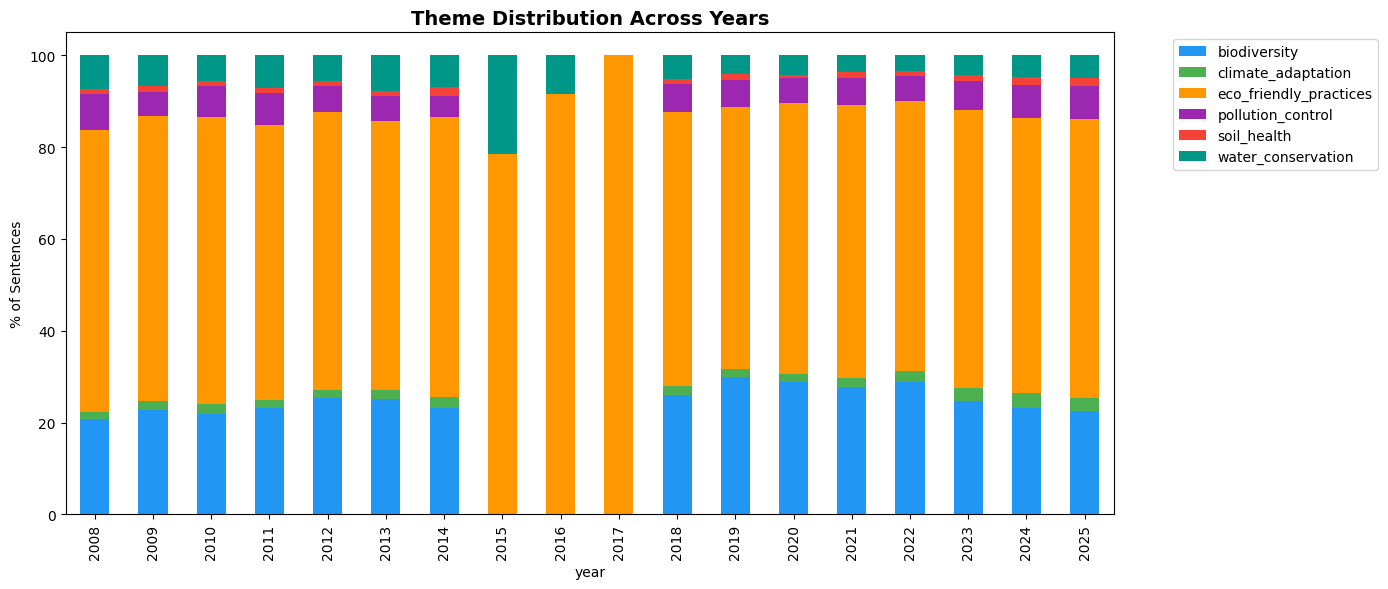

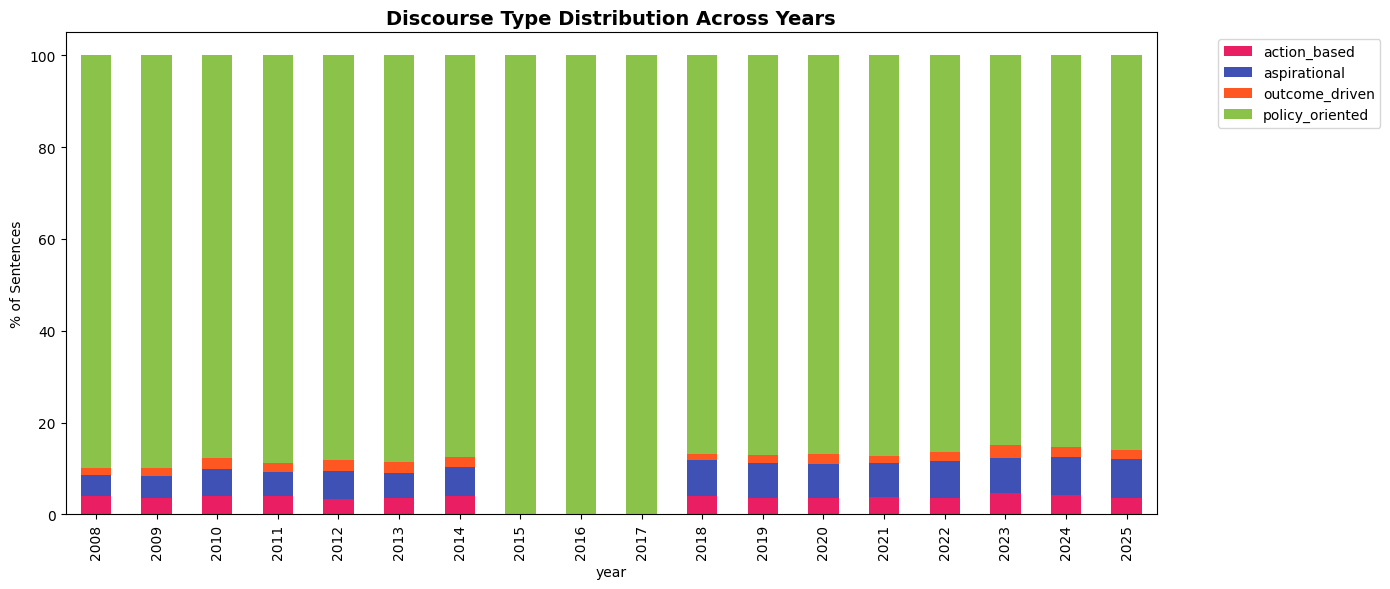

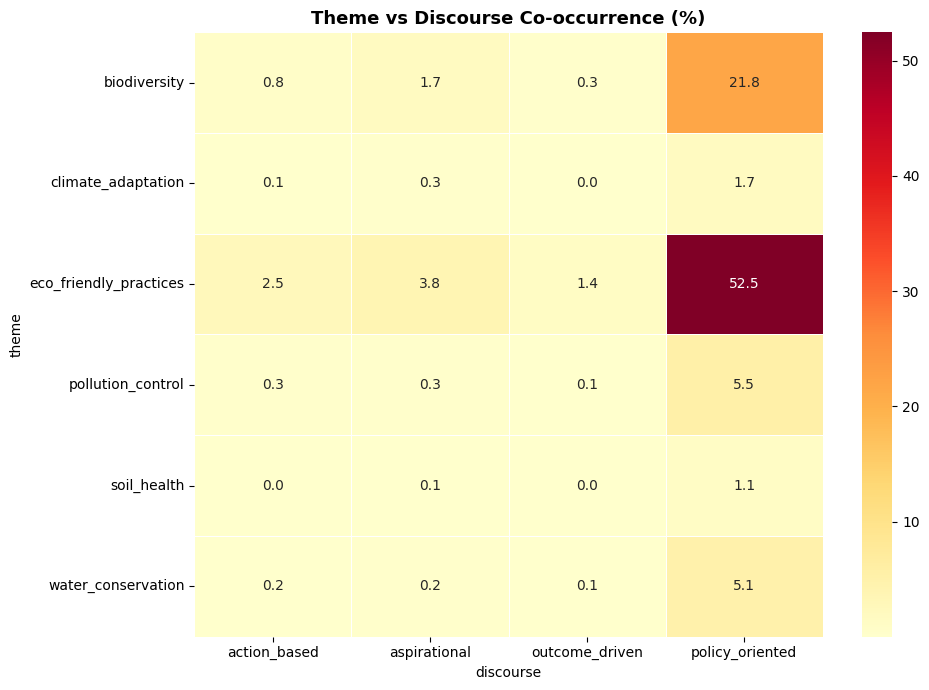

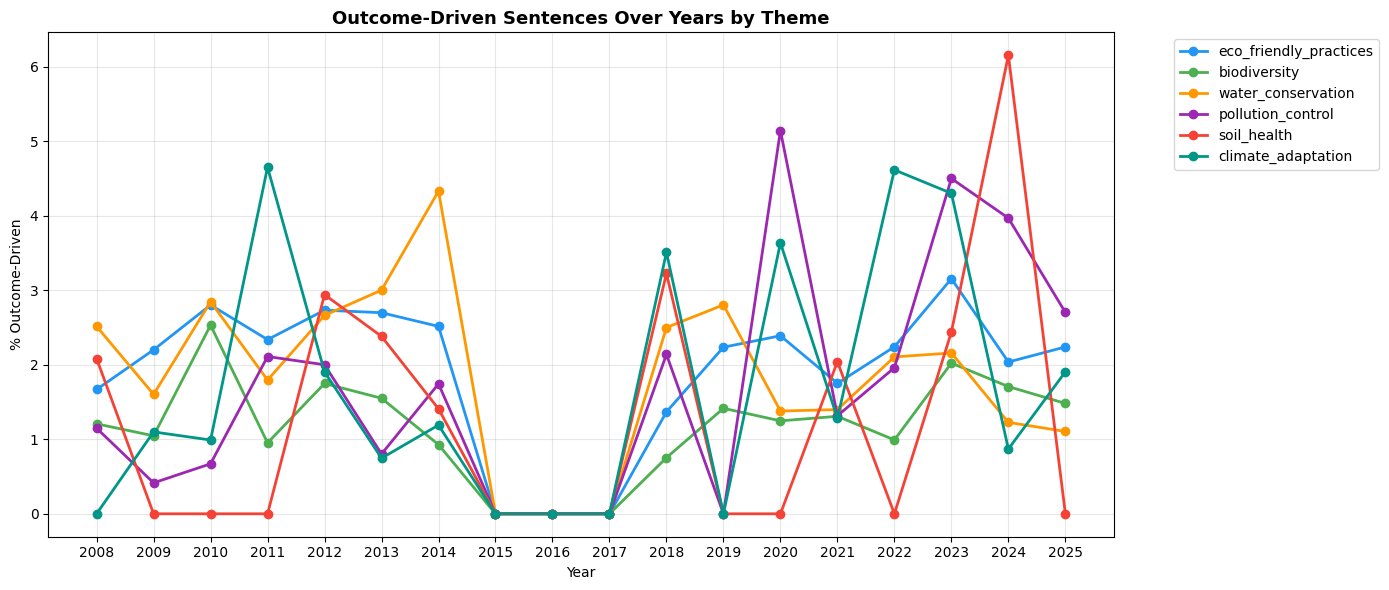


✅ All visualizations saved to outputs/visualizations/


In [ ]:
# ════════════════════════════════════════════════
# STEP 8 — Visualizations
# ════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

df_r = pd.read_csv('results/classified_sentences.csv')
df_r['year'] = df_r['year'].astype(str)
THEME_C = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#009688']
DISC_C  = ['#E91E63','#3F51B5','#FF5722','#8BC34A']

# Chart 1 — Theme over years
pivot = df_r.groupby(['year','theme']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
ax = pivot_pct.plot(kind='bar', stacked=True, figsize=(14,6), color=THEME_C)
ax.set_title('Theme Distribution Across Years', fontsize=14, fontweight='bold')
ax.set_ylabel('% of Sentences'); ax.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout(); plt.savefig('outputs/visualizations/01_theme_years.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2 — Discourse over years
pivot2 = df_r.groupby(['year','discourse']).size().unstack(fill_value=0)
pivot2_pct = pivot2.div(pivot2.sum(axis=1), axis=0) * 100
ax2 = pivot2_pct.plot(kind='bar', stacked=True, figsize=(14,6), color=DISC_C)
ax2.set_title('Discourse Type Distribution Across Years', fontsize=14, fontweight='bold')
ax2.set_ylabel('% of Sentences'); ax2.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout(); plt.savefig('outputs/visualizations/02_discourse_years.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 3 — Heatmap
crosstab = pd.crosstab(df_r['theme'], df_r['discourse'])
plt.figure(figsize=(10,7))
sns.heatmap(crosstab.div(crosstab.sum().sum())*100, annot=True, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Theme vs Discourse Co-occurrence (%)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('outputs/visualizations/03_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 4 — Outcome trend by theme
years  = sorted(df_r['year'].unique())
themes = df_r['theme'].unique()
plt.figure(figsize=(14,6))
for i, theme in enumerate(themes):
    pcts = []
    for year in years:
        sub = df_r[(df_r['year']==year) & (df_r['theme']==theme)]
        pcts.append(len(sub[sub['discourse']=='outcome_driven']) / max(len(sub),1) * 100)
    plt.plot(years, pcts, marker='o', label=theme, color=THEME_C[i % len(THEME_C)], linewidth=2)
plt.title('Outcome-Driven Sentences Over Years by Theme', fontsize=13, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('% Outcome-Driven')
plt.legend(bbox_to_anchor=(1.05,1)); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('outputs/visualizations/04_outcome_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ All visualizations saved to outputs/visualizations/')

           ds         y
0  2008-01-01  1.572112
1  2009-01-01  1.757050
2  2010-01-01  2.531063
3  2011-01-01  1.971987
4  2012-01-01  2.425832
5  2013-01-01  2.290406
6  2014-01-01  2.183877
7  2015-01-01  0.000000
8  2016-01-01  0.000000
9  2017-01-01  0.000000
10 2018-01-01  1.372549
11 2019-01-01  1.811175
12 2020-01-01  2.164762
13 2021-01-01  1.583593
14 2022-01-01  1.892857
15 2023-01-01  2.940256
16 2024-01-01  2.098695
17 2025-01-01  2.000556


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 13.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


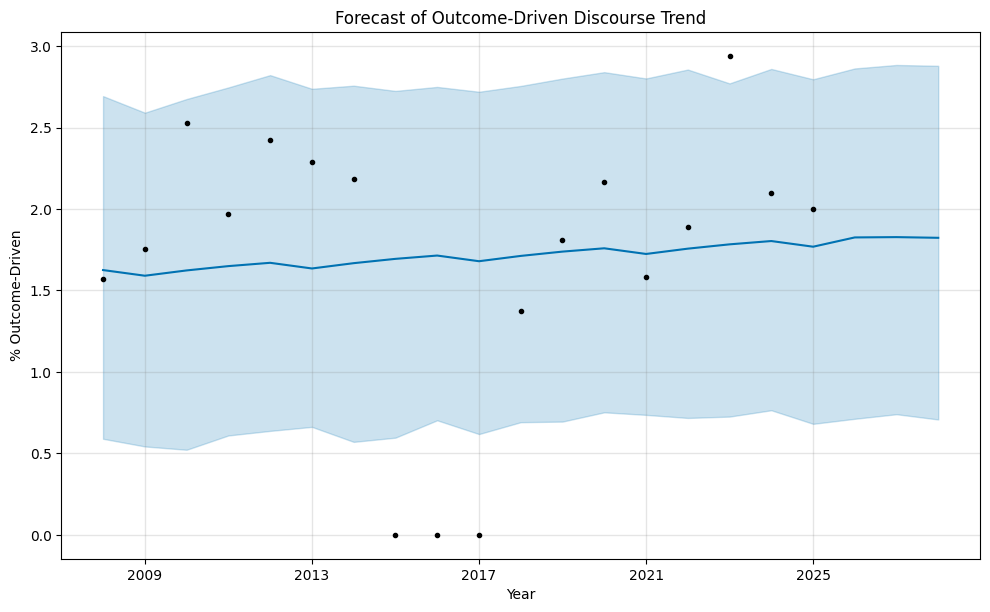

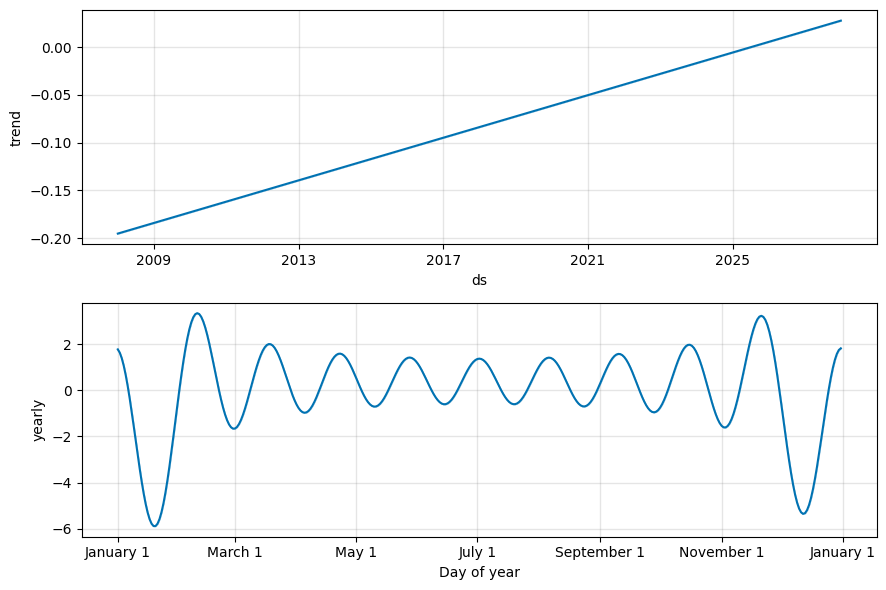

,ds,yhat,yhat_lower,yhat_upper
16,2024-01-01,1.803686,0.764688,2.860405
17,2025-01-01,1.768881,0.681209,2.796970
18,2025-12-31,1.825868,0.712176,2.863503
19,2026-12-31,1.827748,0.740262,2.884839
20,2027-12-31,1.823515,0.707934,2.879760


In [ ]:
# ═══════════════════════════════════════════
# STEP 9 — Time Series Forecasting
# Predict future outcome-driven discourse trend
# ═══════════════════════════════════════════

!pip install -q prophet

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Prepare yearly outcome-driven %
yearly = []

years = sorted(df_r['year'].unique())

for year in years:
    sub = df_r[df_r['year'] == year]
    pct = len(sub[sub['discourse'] == 'outcome_driven']) / len(sub) * 100
    yearly.append([year, pct])

forecast_df = pd.DataFrame(yearly, columns=['ds', 'y'])

# convert year to datetime
forecast_df['ds'] = pd.to_datetime(forecast_df['ds'], format='%Y')

print(forecast_df)

# Train Prophet model
model = Prophet()
model.fit(forecast_df)

# Predict next 3 years
future = model.make_future_dataframe(periods=3, freq='Y')
forecast = model.predict(future)

# Plot forecast
fig = model.plot(forecast)
plt.title("Forecast of Outcome-Driven Discourse Trend")
plt.xlabel("Year")
plt.ylabel("% Outcome-Driven")
plt.show()

# Optional components
fig2 = model.plot_components(forecast)
plt.show()

# Save forecast values
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(5)

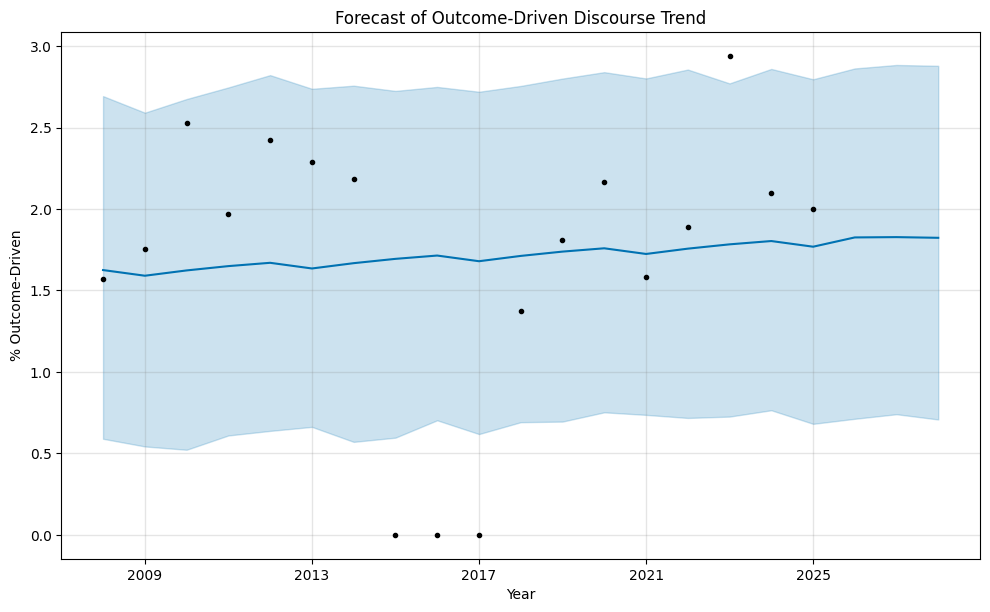

In [ ]:
# Main forecast graph
fig1 = model.plot(forecast)
plt.title("Forecast of Outcome-Driven Discourse Trend")
plt.xlabel("Year")
plt.ylabel("% Outcome-Driven")
plt.savefig('outputs/visualizations/05_forecast_trend.png', dpi=150, bbox_inches='tight')
plt.show()

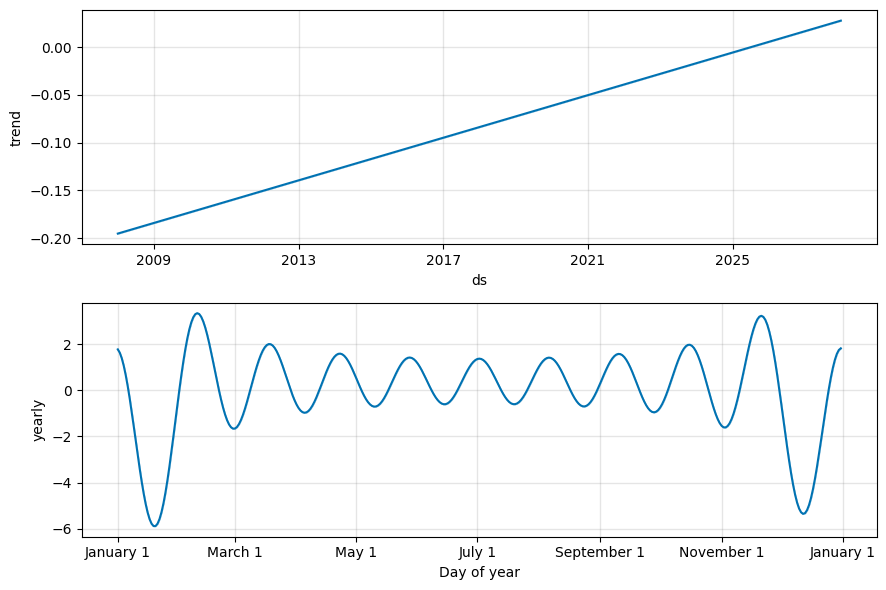

In [ ]:
# Components graph
fig2 = model.plot_components(forecast)
plt.savefig('outputs/visualizations/06_forecast_components.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import shutil, os
from google.colab import files

# create final folder
os.makedirs('final_outputs', exist_ok=True)

# copy results folder
if os.path.exists('results'):
    shutil.copytree('results', 'final_outputs/results', dirs_exist_ok=True)

# copy all visualizations
if os.path.exists('outputs/visualizations'):
    shutil.copytree('outputs/visualizations', 'final_outputs/visualizations', dirs_exist_ok=True)

# create zip
shutil.make_archive('final_outputs', 'zip', 'final_outputs')

# download zip
files.download('final_outputs.zip')

print("✅ final_outputs.zip downloading...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ final_outputs.zip downloading...


In [ ]:
import os
os.listdir()


['.config', 'sample_data']